In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [69]:
df_DE = df[df["job_title_short"]=="Data Engineer"].copy()

In [70]:
df_DE["job_posted_month"] = df_DE["job_posted_date"].dt.month

In [71]:
df_DE_expl = df_DE.explode(column="job_skills")

In [72]:
df_DE_pivot = df_DE_expl.pivot_table(index="job_posted_month",columns="job_skills",aggfunc="size",fill_value=0)

In [73]:
df_DE_pivot.loc["total"]=df_DE_pivot.sum()

In [74]:
df_DE_pivot = df_DE_pivot[df_DE_pivot.loc["total"].sort_values(ascending=False).index]

In [75]:
df_DE_pivot.drop(index="total",inplace=True)

In [ ]:
df_DE_pivot.reset_index(inplace=True)

df_DE_pivot["job_posted_month"] = df_DE_pivot["job_posted_month"].apply(lambda x: pd.to_datetime(x,format="%m").strftime("%B"))

df_DE_pivot.set_index("job_posted_month",inplace=True)

job_skills,sql,python,aws,azure,spark,java,kafka,hadoop,scala,databricks,...,shogun,fastify,workfront,dlib,ember.js,homebrew,asp.netcore,linode,chainer,dingtalk
job_posted_month,,,,,,,,,,,,,,,,,,,,,
January,12987,12426,6924,7138,6567,4246,3687,3533,3517,3002,...,2,0,0,0,0,0,0,0,0,0
February,9792,9378,5446,5278,4948,3300,2809,2774,2625,2272,...,1,0,0,0,0,0,0,0,0,0
March,9831,9410,5580,5283,4764,3223,2689,2592,2621,2378,...,0,0,0,0,0,0,0,0,0,0
April,8975,8670,5012,4901,4316,2931,2329,2340,2373,2170,...,0,0,0,0,0,3,0,0,1,0
May,8411,8169,4768,4466,3991,2725,2166,2195,2132,2034,...,0,0,0,0,0,0,1,0,0,0
June,9713,9216,5280,5091,4654,3092,2516,2468,2464,2317,...,0,0,1,0,0,0,0,0,0,0
July,9032,8493,5015,4857,4044,2757,2296,2235,2213,2161,...,0,0,2,2,0,0,0,0,0,0
August,9565,9016,5330,5070,4436,2961,2468,2421,2427,2310,...,0,0,1,0,0,0,1,0,0,0
September,8663,8213,4612,4646,3902,2584,2088,2024,2070,2198,...,1,0,0,0,0,0,0,1,0,0


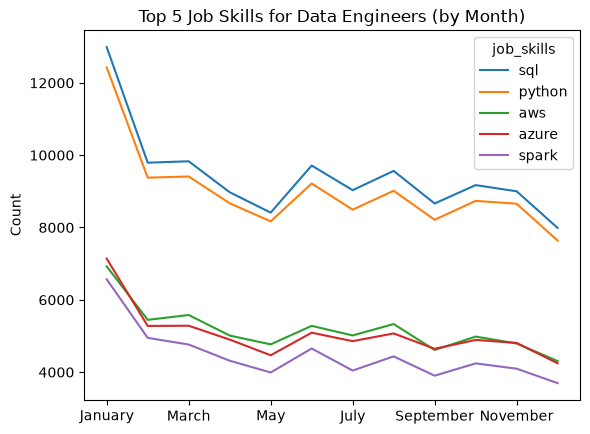

In [77]:
df_DE_pivot.iloc[:,:5].plot(kind="line")

plt.title("Top 5 Job Skills for Data Engineers (by Month)")
plt.ylabel("Count")
plt.xlabel("")
plt.show()